In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import plotly.express as px
from scipy.stats import norm
from scipy import optimize
import sympy

# Introduction to numerical methods

János Török

# CLass 10:Fourier transformation
The functions $\sin(k\omega t)$ and $\cos(j\omega t)$ form a basis in the space of periodic functions over the interval $[0,T]$, where $T=2\pi/\omega$
$$
\begin{align}
\int_0^T\sin(k\omega t)\sin(j\omega t)dt &= \frac{T}{2}\delta_{kj}\cr
\int_0^T\cos(k\omega t)\cos(j\omega t)dt &= \frac{T}{2}\delta_{kj}\cr
\int_0^T\sin(k\omega t)\cos(j\omega t)dt &= 0
\end{align}
$$

In [4]:
def Riemann_C(f,a,b,h):
    t = np.arange(a, b, h)
    I = (f(t+h/2) * h).sum()
    return I

In [5]:
def ss(k,j,h=0.01):
    t = np.arange(0,1,h)
    return (np.sin(t*k*2*np.pi)*np.sin(t*j*2*np.pi)).sum() * h
def cc(k,j,h=0.01):
    t = np.arange(0,1,h)
    return (np.cos(t*k*2*np.pi)*np.cos(t*j*2*np.pi)).sum() * h
def sc(k,j,h=0.01):
    t = np.arange(0,1,h)
    return (np.sin(t*k*2*np.pi)*np.cos(t*j*2*np.pi)).sum() * h

In [6]:
ss(2,2),cc(2,2),sc(2,2)

(0.5000000000000001, 0.5000000000000001, -1.457167719820518e-17)

In [7]:
ss(2,1),cc(2,1),sc(2,1)

(-3.2265856653168614e-17, 2.55351295663786e-17, 3.4139358007223563e-17)


## Discrete Fourier transform
We can use the sine and cosine functions to express any periodic function:
$$f(t,T) = \sum_{k=1}^\infty [a_k\sin(k\omega t)+b_k\cos(k\omega t)] +\frac{b_0}{2}$$

Using the basis nature of the sine and cosine functions we can express the coefficients $a_k$, $b_k$ as follows:
$$\begin{align}
a_k&=\frac{2}{T}\int_0^T f(t,T)\sin(k\omega t)dt\cr
b_k&=\frac{2}{T}\int_0^T f(t,T)\cos(k\omega t)dt
\end{align}$$

In [8]:
ta = np.linspace(0,1,100)

In [9]:
ft = ta * (1-ta)

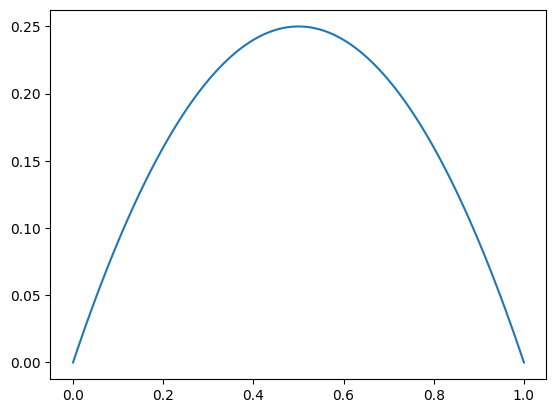

In [10]:
plt.plot(ta,ft)

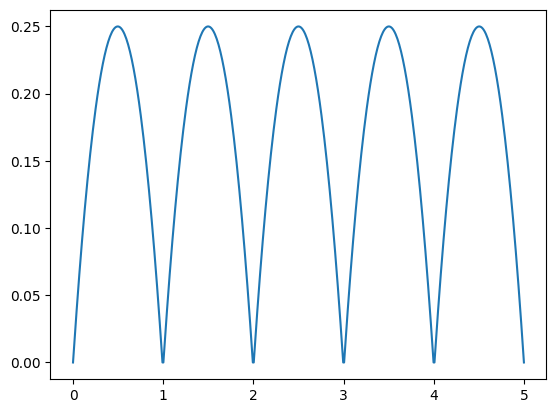

In [11]:
# The idea is that it is periodic:
tp = np.linspace(0,5,500)
ftp = list(ft) * 5
plt.plot(tp,ftp)

In [63]:
def dft(t,f,nmax=10):
    T = t.max()
    h = t[1:] - t[:-1]
    fm = (f[1:] + f[:-1])/2
    tm = (t[1:] + t[:-1])/2
    a = np.zeros(nmax,dtype=float)
    b = np.zeros(nmax,dtype=float)
    for k in range(nmax):
        a[k] = 2*(np.sin(tm*k*2*np.pi/T)*fm*h).sum() / T
        b[k] = 2*(np.cos(tm*k*2*np.pi/T)*fm*h).sum() / T
    b[0] /= 2
    return a,b

In [13]:
a,b = dft(ta,ft)

### Discrete Fourier spectrum

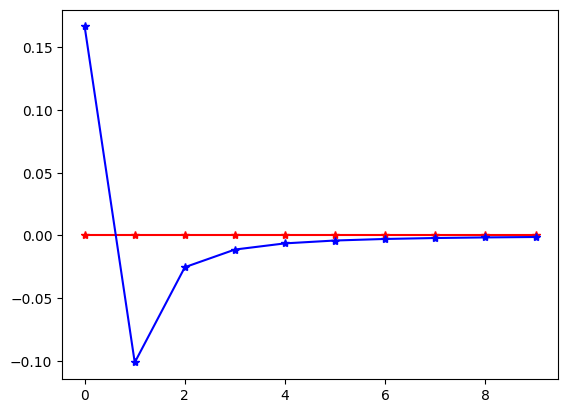

In [14]:
plt.plot(a,"r*-")
plt.plot(b,"b*-")

#### Observations
 * All $a_k$ is zero, as the function is even
 * The coefficients $b_k$ decrease really rapidly, in spite of the fact that our "periodic" function is not differentiable at the bounday

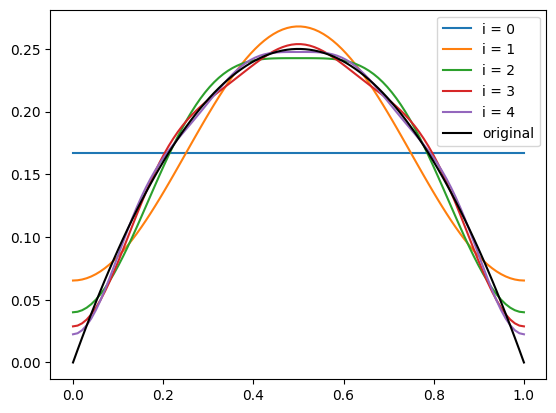

In [15]:
ff = ta * 0
for i in range(5):
    ff = ff + b[i] * np.cos(i * np.pi * 2 * ta)
    plt.plot(ta,ff,label="i = %d" % (i))
plt.plot(ta,ft,"k-",label="original")
plt.legend()

### Get rid of high frequency noise
low pass filter

In [16]:
f2t = ft + np.random.normal(loc=0,scale=0.1,size=len(ft))

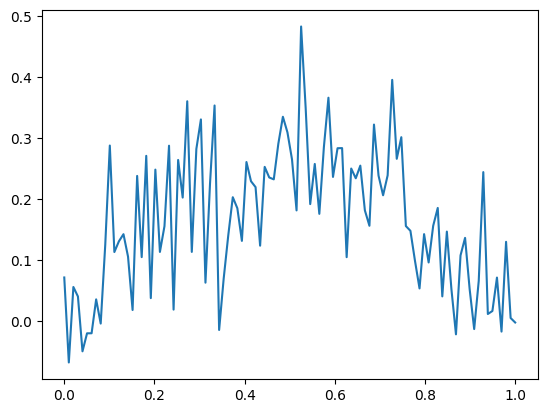

In [17]:
plt.plot(ta,f2t)

In [18]:
a,b = dft(ta,f2t)

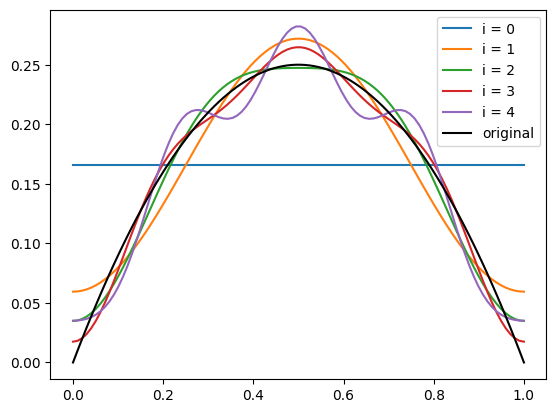

In [19]:
ff = ta * 0
for i in range(5):
    ff = ff + b[i] * np.cos(i * np.pi * 2 * ta)
    plt.plot(ta,ff,label="i = %d" % (i))
plt.plot(ta,ft,"k-",label="original")
plt.legend()

## Non-periodic functions:
Here we extend the periodic disrete Fourier transform to non-periodic functions. The idea is that if the function is defined in the $[0,T]$ interval, then we take the periodic interval as $[0,T']$ with $T'\to\infty$.

<img src="class09/fouriernemperiodikus.png" width=400px>


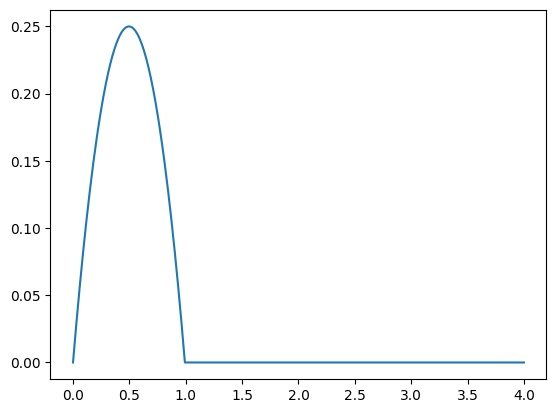

In [20]:
Tp = 4
tap = np.linspace(0,Tp,100*Tp)
fp = np.zeros_like(tap)
fp[:len(ft)] = ft
plt.plot(tap,fp)

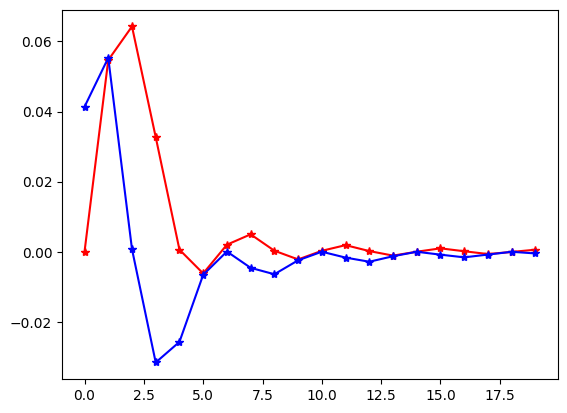

In [21]:
a,b = dft(tap,fp,nmax=20)
plt.plot(a,"r*-")
plt.plot(b,"b*-")

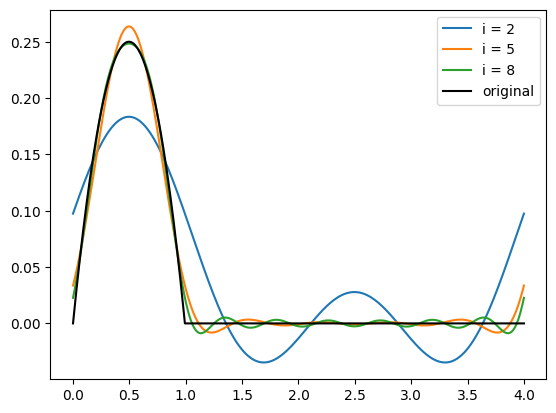

In [25]:
ff = tap * 0
for i in range(10):
    ff = ff + b[i] * np.cos(i * np.pi * 2 * tap/tap.max()) + a[i] * np.sin(i * np.pi * 2 * tap/tap.max())
    if i % 3 == 2:
        plt.plot(tap,ff,label="i = %d" % (i))
plt.plot(tap,fp,"k-",label="original")
plt.legend()

Number of important modes increase with $T'$. The DFT in $\omega'=2\pi/T'$:
$$
f_{T'}(t)=\frac{b_{0,T'}}{2}+\sum _{k=1}^{\infty }
\left[a_{k,T'}\sin(k\omega' t)+
b_{k,T'}\cos(k\omega' t)\right].
$$
Now let us take the
$$f(t)=\lim_{T'\to\infty}f_{T'}(t)$$
This also means $\Delta\omega'=\omega'=2\pi/T'\to 0$, while all the coefficients also go to zeros.
$$
f(t)=\lim_{T'\to\infty}f_{T'}(t)=
\lim_{T'\to\infty}\sum _{k=1}^{\infty }
\left[A_{k,T'}\sin(k\omega' t)+
B_{k,T'}\cos(k\omega' t)\right]\Delta\omega'.
$$
We take the continuous limit:
$$f(t)=\frac{1}{\sqrt{2\pi}}\int_0^\infty [A(\omega)\sin(\omega t)+B(\omega)\cos(\omega t)]
d\omega,$$
where we included a $1/\sqrt{2\pi}$ factor which will be explained later. This is the inverse Fourier transform, when the function in real space is recovered from the Fourier components. The Fourier components can be obtained using the Fourier transform:
$$
\begin{align}
A(\omega)&=\frac{1}{\sqrt{2\pi}}\int_{-\infty}^\infty f(t)\sin(\omega t)dt\\
B(\omega)&=\frac{1}{\sqrt{2\pi}}\int_{-\infty}^\infty f(t)\cos(\omega t)dt.
\end{align}$$
Here one can see that we split the $2\pi$ factor evenly between the forward and inverse transformation.

We will see than it is easier to do the whole transformation using the complex numbers:
$$\sin(\omega t)=\frac{e^{i\omega t}-e^{-i\omega t}}{2i}\qquad
\cos(\omega t)=\frac{e^{i\omega t}+e^{-i\omega t}}{2}$$
Let us define the complex Fourier transform of $f(t)$ as:
$$\widehat F(\omega)=\frac{1}{2}[B(\omega)-iA(\omega)].$$
Now we combine the expressions for $A(\omega)$ and $B(\omega)$:
$$\widehat F(\omega)=\frac{1}{\sqrt{2\pi}}\int_{-\infty}^\infty f(t)e^{-i\omega t} dt.$$

The function $f(t)$ can be expressed in the following form:
$$\begin{align}
f(t)&=\frac{1}{\sqrt{2\pi}}
\int_0^\infty e^{i\omega t}\left[\frac{A(\omega)}{2i}+
\frac{B(\omega)}{2}\right]+
e^{-i\omega t}\left[-\frac{A(\omega)}{2i}+
\frac{B(\omega)}{2}\right]d\omega= \cr
&=\frac{1}{\sqrt{2\pi}}\int_0^\infty
e^{i\omega t}\underbrace{\frac{1}{2} \left[B(\omega)-iA(\omega)\right]}_{\widehat
F(\omega)}+
e^{-i\omega t}\underbrace{\frac{1}{2} \left[B(\omega)+iA(\omega)\right]}_{\widehat
F^\ast(\omega)} d\omega
\end{align}$$

We know that the sine function is odd and the cosine is even so we can set the following relations:
$$A(-\omega)=-A(\omega),\qquad B(-\omega)=+B(\omega).$$
These relations allow us to rewrite $f(t)$:
$$\begin{align}
f(t)&=\frac{1}{\sqrt{2\pi}}
\int_0^\infty \left[\widehat F(\omega) e^{i\omega t} \right]d\omega +
\int_0^\infty\left[\widehat F^\ast(\omega) e^{-i\omega t} \right]d\omega =
\cr
&=\frac{1}{\sqrt{2\pi}}\int_0^\infty\left[\widehat F(\omega) e^{i\omega t} \right]d\omega +
\int_{-\infty}^0\left[\widehat F^\ast(-\omega') e^{+i\omega' t}\right]d\omega'=\cr
&=\frac{1}{\sqrt{2\pi}}\int_{-\infty}^\infty\widehat F(\omega) e^{i\omega t} d\omega
\end{align}$$
We can summerize the results as
$$
\begin{align}
f(t)&=\frac{1}{\sqrt{2\pi}}\int_{-\infty}^\infty \widehat f(\omega) e^{i\omega t} d\omega \cr
\widehat f(\omega) &=\frac{1}{\sqrt{2\pi}}\int_{-\infty}^\infty f(t)e^{-i\omega t}dt
\end{align}$$
The requirement of the Fourier transform to exist:
$$\int_{-\infty}^\infty|f(t)|dt < \infty$$

## Dirac delta
Let us calculate the inverse Fourier transform of the Fourier transform of any function, which should be the function itself.
$$\begin{align}
f(t)&=\frac{1}{\sqrt{2\pi}}
\int_{-\infty}^\infty\frac{1}{\sqrt{2\pi}}\left(\int_{-\infty}^\infty f(t')e^{-i\omega t'}dt'\right)
e^{i\omega t}d\omega= \cr
&=\int_{-\infty}^\infty\int_{-\infty}^\infty \frac{1}{2\pi}f(t')e^{i\omega(t-t')}dt'd\omega=\cr
&=\int_{-\infty}^\infty f(t')\left(\frac{1}{2\pi}\int_{-\infty}^\infty
e^{i\omega(t-t')}d\omega\right)dt'\cr
f(t)&=\int_{-\infty}^\infty f(t')\delta(t-t')dt'
\end{align}$$
The last row is the definition of the Dirac delta, which gives us the Fourier transform of the Dirac delta:
$$\delta(t)=\frac{1}{\sqrt{2\pi}}\int_{-\infty}^\infty \frac{1}{\sqrt{2\pi}}e^{i\omega t}d\omega$$

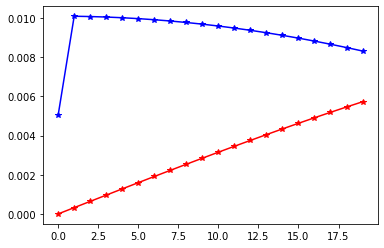

In [5]:
# Let us try it
ta = np.linspace(0,1,100)
ft = np.zeros_like(ta)
ft[0] = 1
a,b = dft(ta,ft,nmax=20)
plt.plot(a,"r*-")
plt.plot(b,"b*-")

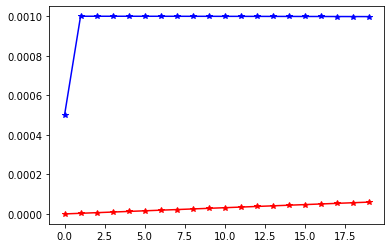

In [13]:
# it increase number of points
ta = np.linspace(0,1,1000)
ft = np.zeros_like(ta)
ft[0] = 1
a,b = dft(ta,ft,nmax=20)
plt.plot(a,"r*-")
plt.plot(b,"b*-")

## Some operations in the Fourier space
We denote the Fourier transformation with curly ${\cal F}$.
$$\begin{align}
{\cal F}\left[\frac{d}{dt}f(t)\right]&=i\omega{\cal F}[f(t)]\\
{\cal F}[f(t-t_0)]&=e^{-i\omega t_0} {\cal F}[f(t)]
\end{align}$$

### Let us try the time shift rule
So if the Dirac delta is at position $t_0$, then we should add a complex multiplier of:
$$e^{-i\omega t_0} = \cos(\omega t_0) - i\sin(\omega t_0)$$

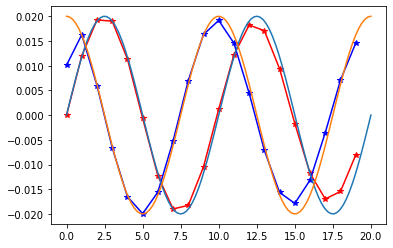

In [57]:
# Let us try it
t0 = 10
NP = 100
nmax = 20
ta = np.linspace(0,1,NP)
ft = np.zeros_like(ta)
ft[t0] = 1
a,b = dft(ta,ft,nmax=nmax)
plt.plot(a,"r*-")
plt.plot(b,"b*-")
plt.plot(ta*nmax,np.sin(ta*2*t0*np.pi/NP*nmax)/NP*2)
plt.plot(ta*nmax,np.cos(ta*2*t0*np.pi/NP*nmax)/NP*2)

### Derivation rule:
$$\frac{d}{dt}\sin(at) = a\cos(at)$$

In [ ]:
# Let us try it
t0 = 10
NP = 100
nmax = 20
ta = np.linspace(0,1,NP)
ft = np.sin(ta*2*np.pi * 3)
ft[t0] = 1
a,b = dft(ta,ft,nmax=nmax)
plt.plot(a,"r*-")
plt.plot(b,"b*-")
plt.plot(ta*nmax,np.sin(ta*2*t0*np.pi/NP*nmax)/NP*2)
plt.plot(ta*nmax,np.cos(ta*2*t0*np.pi/NP*nmax)/NP*2)

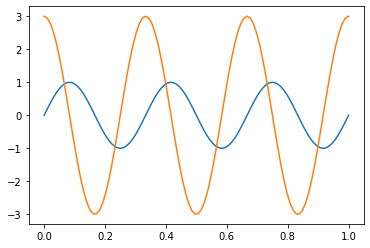

In [64]:
# Let us try it
t0 = 10
NP = 100
nmax = 20
ta = np.linspace(0,1,NP)
ft = np.sin(ta*2*np.pi * 3)
dtft = 3 * np.cos(ta*2*np.pi * 3)
plt.plot(ta,ft)
plt.plot(ta,dtft)

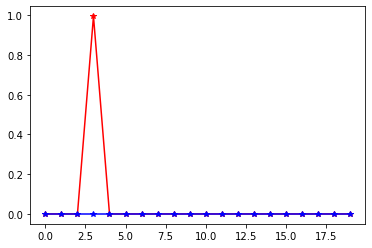

In [67]:
a,b = dft(ta,ft,nmax=nmax)
plt.plot(a,"r*-")
plt.plot(b,"b*-")

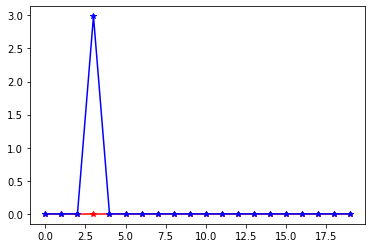

In [68]:
ad,bd = dft(ta,dtft,nmax=nmax)
plt.plot(ad,"r*-")
plt.plot(bd,"b*-")

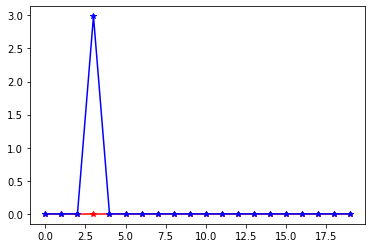

In [70]:
a,b = dft(ta,ft,nmax=nmax)
w = np.arange(len(a))
plt.plot(w,b*w,"r*-")
plt.plot(w,a*w,"b*-")

In [77]:
def DFT(t,f):
    N = len(t)
    w = np.arange(N).reshape((N, 1))
    e = np.exp(-1.j* w * t) 
    F = np.dot(e, f)
    return F

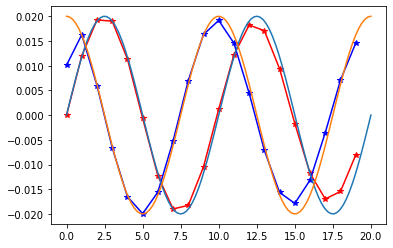

In [78]:
# Let us try it
t0 = 10
NP = 100
nmax = 20
ta = np.linspace(0,1,NP)
ft = np.zeros_like(ta)
ft[t0] = 1
a,b = dft(ta,ft,nmax=nmax)
plt.plot(a,"r*-")
plt.plot(b,"b*-")
plt.plot(ta*nmax,np.sin(ta*2*t0*np.pi/NP*nmax)/NP*2)
plt.plot(ta*nmax,np.cos(ta*2*t0*np.pi/NP*nmax)/NP*2)

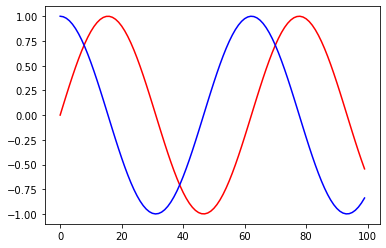

In [83]:
fhat = DFT(ta,ft)
plt.plot(-np.imag(fhat),"r-")
plt.plot(np.real(fhat),"b-")

### Other types of Fourier transform
$$\large x_n=\frac{1}{N}\sum_{k=0}^{N-1}X_k \cdot e^{i\cdot 2\pi kn/N}$$


In [42]:
def DFT_x(x):
    N = len(x)
    n = np.arange(N)
    k = n.reshape((N, 1))
    e = np.exp(-2.j * np.pi * k * n / N) 
    X = np.dot(e, x)
    return X

# Fast Fourier Transform (FFT)
(Source: <a href="https://lloydrochester.com/post/dsp/fast-fourier-transform/">https://lloydrochester.com/post/dsp/fast-fourier-transform/</a>)

First we start with the definition of the DFT:
$$X_k = \sum_ {n=0}^ {N-1}x_n e^{-2 \pi i k n / N} = \sum_ {n=0}^ {N-1}x_n W_{N}^{kn},$$
where $W_{N}^{kn} = e^{-2 \pi i k n / N}$. Let us note that the complex exonential is periodic in $kn$, namely that the only thing which matters is $kn \% N$, where % is for the modulo operation.
## FFT Example of size 8
In my opinion the best to way to understand the FFT is using an example of size 8 or where $N=8$. The reason for this is for smaller $N$ we don’t have enough stages, and for larger N the math becomes untamely. Stand by as we walk through a concrete example. The Fourier components are obtained using the following matrix multipication:
$$X_k = \sum_ {n=0}^ {8-1}x_n W_{8}^{kn}$$
Visualizing the matrix helps for understanding:
$$\begin{bmatrix}
X_0 \\
X_1 \\
X_2 \\
X_3 \\
X_4 \\
X_5 \\
X_6 \\
X_7
\end{bmatrix} =
\begin{bmatrix}
W_{8}^{0} & W_{8}^{0} & W_{8}^{0} & W_{8}^{0} & W_{8}^{0} & W_{8}^{0} & W_{8}^{0} & W_{8}^{0} \\
W_{8}^{0} & W_{8}^{1} & W_{8}^{2} & W_{8}^{3} & W_{8}^{4} & W_{8}^{5} & W_{8}^{6} & W_{8}^{7} \\
W_{8}^{0} & W_{8}^{2} & W_{8}^{4} & W_{8}^{6} & W_{8}^{0} & W_{8}^{2} & W_{8}^{4} & W_{8}^{6} \\
W_{8}^{0} & W_{8}^{3} & W_{8}^{6} & W_{8}^{1} & W_{8}^{4} & W_{8}^{7} & W_{8}^{2} & W_{8}^{5} \\
W_{8}^{0} & W_{8}^{4} & W_{8}^{0} & W_{8}^{4} & W_{8}^{0} & W_{8}^{4} & W_{8}^{0} & W_{8}^{4} \\
W_{8}^{0} & W_{8}^{5} & W_{8}^{2} & W_{8}^{7} & W_{8}^{4} & W_{8}^{1} & W_{8}^{6} & W_{8}^{3} \\
W_{8}^{0} & W_{8}^{6} & W_{8}^{4} & W_{8}^{2} & W_{8}^{0} & W_{8}^{6} & W_{8}^{4} & W_{8}^{2} \\
W_{8}^{0} & W_{8}^{7} & W_{8}^{6} & W_{8}^{5} & W_{8}^{4} & W_{8}^{3} & W_{8}^{2} & W_{8}^{1}
\end{bmatrix}
\begin{bmatrix}
x_0 \\
x_1 \\
x_2 \\
x_3 \\
x_4 \\
x_5 \\
x_6 \\
x_7
\end{bmatrix}$$

### Efficiency
In the general case we need $N^2$ complex multiplications for this matrix operation. The question is whether we can do better. We can observe that some components of the matrix are the same. Can we use this to be more efficient? The answer is yes and we can bring down the number of calculations to $N\log(N)$!

The algorithm un a nutshell:
The Cooley-Tukey FFT algorithm breaks the DFT into smaller DFTs. Sometimes this is referred to as recursion. There are three parts to this algorithm that we should highlight before we get to the math.

 1. We will divide the even and odd indices of our input $x_n$ as many times as it takes to get tuples
 2. When we compute each part of $X_k$ we will do this in stages where we can use computations from previous stages.
 3. We will exploit the symmetry of the cosine and sine functions to reduce our work.
 
Breaking down a time series into even and odd parts is also called “Decimation in Time”. For audio say our input to the FFT is a series of samples in time.

### Breaking the DFT into even and odd parts
Let’s start with an example with an input of size 8. Watch me break this down into 3 stages until we arrive with 4 pairs of tuples:
$$
\begin{pmatrix}
x_0 & x_1 & x_2 & x_3 & x_4 & x_5 & x_6 & x_7
\end{pmatrix}$$
$$\begin{pmatrix}
x_0 & x_2 & x_4 & x_6
\end{pmatrix}
\begin{pmatrix}
x_1 & x_3 & x_5 & x_7
\end{pmatrix}$$
$$\begin{pmatrix}
x_0 & x_4
\end{pmatrix}
\begin{pmatrix}
x_2 & x_6
\end{pmatrix}
\begin{pmatrix}
x_1 & x_5
\end{pmatrix}
\begin{pmatrix}
x_3 & x_7
\end{pmatrix}
$$
We show that this subdivision helps us to reduce the number of operations.

### Derive Decimation in time for the General Case
Let’s now take the DFT function and break it down into two DFTs by even and odd numbered indices:
$$\begin{align}
\sum_ {n=0}^ {N-1}x_n e^{-2 \pi i k n / N}
&= \sum_ {m=0}^ {N/2-1}x_{2m} e^{-2 \pi i k (2m) / N} + \sum_ {m=0}^ {N/2-1}x_{2m+1} e^{-2 \pi i k (2m+1) / N}\\
&= \sum_ {m=0}^ {N/2-1}x_{2m} e^{-2 \pi i k (2m) / N} + e^{-2 \pi i k / N} \sum_ {m=0}^ {N/2-1}x_{2m+1} e^{-2 \pi i k (2m) / N}
\end{align}
$$
Let us use the wollowing notation:
$$W_{N}^{kn} = e^{-2 \pi i k n / N}$$
The we have
$$\sum_ {n=0}^ {N-1}x_n W_{N}^{kn}
= \sum_ {m=0}^ {N/2-1}x_{2m} W_{N/2}^{km} + W_{N}^{k} \sum_ {m=0}^ {N/2-1}x_{2m+1} W_{N/2}^{km}$$
This can be summerized into
$$X_k = E_k + W_N^k O_k$$
As an exercise to the reader we can also drive the following.
$$X_{k+\frac{N}{2}} = E_k - W_N^k O_k$$
Let us summarize it:
$$
\begin{align}
X_k &= E_k + W_N^k O_k\\
X_{k+\frac{N}{2}} &= E_k - W_N^k O_k
\end{align}
$$
Let’s stop to look at what we’ve derived.

 1. The DFT $X_k$ is broken down to an even $E_k$ and odd part $O_k$
 2. The DFT is symmetric as the $X_k$  and $X_{k+\frac{N}{2}}$  differ only by a minus sign on the odd part.
 3. The odd part is multiped by a constant $W_N^k$ that doesn’t depend on $n$ or the inputs $x_n$.
 
Now we can keep breaking the even and odd parts further until we cannot do so anymore. This will leave us with groups of tuples.

### Recursive Breakdown
Let’s use 3 steps to break down the FFT for $N=8$. As you’ll see 3-stages is the farthest we can break it down.
$$
\begin{equation}
\begin{split}
X_k & = \sum_ {n=0}^ {8-1}x_n W_{8}^{kn} \\
& = \sum_ {m=0}^ {4-1}x_{2m} W_{4}^{km} + W_{8}^{k} \sum_ {m=0}^ {4-1}x_{2m+1} W_{4}^{km} \\
& = ( \sum_ {p=0}^ {2-1}x_{2p} W_{2}^{kp} + W_{4}^{k} \sum_ {p=0}^ {2-1}x_{2p+1} W_{2}^{kp}) + W_{8}^{k}( \sum_ {p=0}^{2-1}x_{2p} W_{2}^{kp} + W_4^k \sum_{p=0}^{2-1}x_{2p+1} W_{2}^{kp})  \\
& = (x_0+x_4 W_2^k) + W_4^k (x_2+x_6 W_2^k) + W_8^k ( (x_1+x_5 W_2^k) + W_4^k (x_3+x_7 W_2^k))
\end{split}
\end{equation}$$
For the last equation we used $W_2^0=1$ and $p=2m$ for a fully broken down DFT of size 8.
#### Stage 1: Four sets of Tuples

For our first stage we will compute, and store in temporary locations each of the inner most expressions:
$$\begin{align}
S_1^0 &= (x_0+x_4 W_2^k) \\
S_1^1 &= (x_2+x_6 W_2^k) \\
S_1^2 &= (x_1+x_5 W_2^k) \\
S_1^3 &= (x_3+x_7 W_2^k)
\end{align}$$
As we’ll see later the weights $W_2^k$ only take on 2 values, leaving 8 values to store.

#### Stage 2: Two parts of Four
$$\begin{align}
S_2^0 &= S_1^0 + W_4^k S_1^1 \\
S_2^1 &= S_1^2 + W_4^k S_1^3
\end{align}$$
Although we have two equations Stage 2, the weight $W_4^k$ can take on 4 different values. Again, we have 8 values to store.

#### Stage 3: One part of Eight
$$\begin{align}
S_3^0 &= S_2^0 + W_8^k S_2^1
\end{align}$$
For our third stage we only have one equation, however $W_8^k$ can take on 8 values and thus we have 8 values to store.

### Exploit the Symmetry of the Weights


For our example we have 3 different weights to analyze:
$$\begin{align}
W_2^k \\
W_4^k \\
W_8^k
\end{align}$$
Let’s break this down into 8 values as we have for our example.

#### Weights $W_2^k$
$$W_2^k = e^{- \pi i k } = (-1)^k =
\begin{bmatrix}
1 \\
-1 \\
1 \\
-1 \\
1 \\
-1 \\
1 \\
-1
\end{bmatrix}$$
This weight only takes on two values $W_2^k =\in \{ 1 , -1 \}$.

#### Weights $W_4^k$

$$W_4^k = e^{- \pi i k / 2 } =
\begin{bmatrix}
1 \\
-i \\
-1 \\
i \\
1 \\
-i \\
1 \\
i
\end{bmatrix}$$

This weight only takes on four values $W_4^k =\in \{ 1 , -1, i, -i \}$.

#### Weights $W_8^k$

$$W_8^k = e^{- \pi i k / 4 } =
\begin{bmatrix}
1 \\
\frac{1}{\sqrt{2}}(1-i) \\
-i \\
\frac{1}{\sqrt{2}}(-1-i) \\
-1 \\
\frac{1}{\sqrt{2}}(-1+i) \\
i \\
\frac{1}{\sqrt{2}}(1+i) \\
\end{bmatrix}$$



### Butterfly Diagram
The full equation
$$ X_k
= (x_0+x_4 W_2^k) + W_4^k (x_2+x_6 W_2^k) + W_8^k ( (x_1+x_5 W_2^k) + W_4^k (x_3+x_7 W_2^k))$$
Some examples:
$$\begin{align}
X_0 &= (x_0+x_4) + (x_2+x_6) + (x_1+x_5) + (x_3+x_7) \\
X_1 &= (x_0 - x_4) -i (x_2 - x_6) + \frac{1}{\sqrt{2}}(1-i) ( (x_1 -x_5) - i (x_3 - x_7)) \\
X_4 &= (x_0 + x_4) + (x_2 + x_6) - ( (x_1 +x_5) + (x_3 + x_7))
\end{align}$$
The calculations can be summarized in the following diagram which is called the butterfly diagram. Operations go from right to left.
<img src="class09/fft-butterfly.png" width=400px>

In [43]:
def FFT(x):
    """
    A recursive implementation of 
    the 1D Cooley-Tukey FFT, the 
    input should have a length of 
    power of 2. 
    """
    N = len(x)
    
    if N == 1:
        return x
    else:
        X_even = FFT(x[::2])
        X_odd = FFT(x[1::2])
        factor = \
          np.exp(-2.j*np.pi*np.arange(N)/ N)
        
        X = np.concatenate(\
            [X_even+factor[:int(N/2)]*X_odd,
             X_even+factor[int(N/2):]*X_odd])
        return X

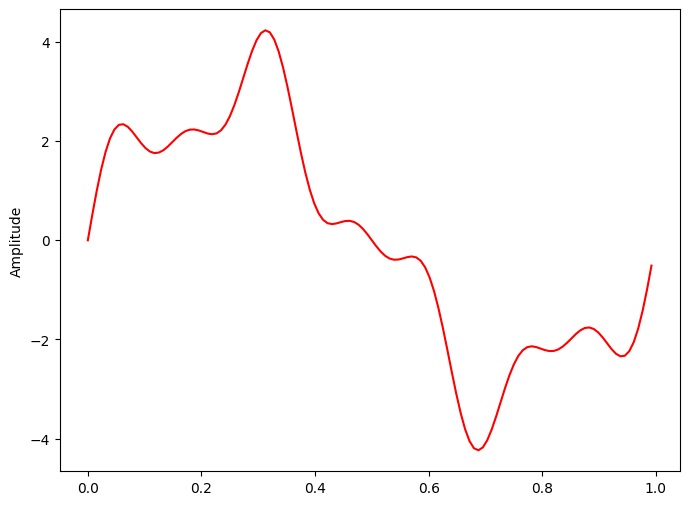

In [44]:
# sampling rate
sr = 128
# sampling interval
ts = 1.0/sr
t = np.arange(0,1,ts)

freq = 1.
x = 3*np.sin(2*np.pi*freq*t)

freq = 4
x += np.sin(2*np.pi*freq*t)

freq = 7   
x += 0.5* np.sin(2*np.pi*freq*t)

plt.figure(figsize = (8, 6))
plt.plot(t, x, 'r')
plt.ylabel('Amplitude')

plt.show()

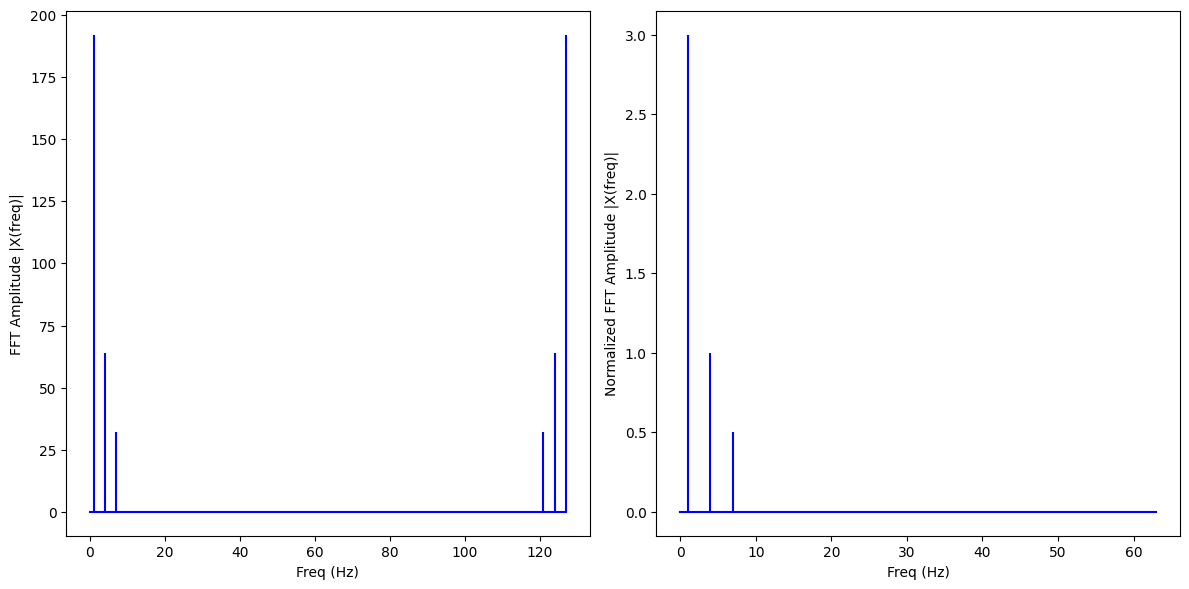

In [45]:
X=FFT(x)

# calculate the frequency
N = len(X)
n = np.arange(N)
T = N/sr
freq = n/T 

plt.figure(figsize = (12, 6))
plt.subplot(121)
plt.stem(freq, abs(X), 'b', \
         markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')

# Get the one-sided specturm
n_oneside = N//2
# get the one side frequency
f_oneside = freq[:n_oneside]

# normalize the amplitude
X_oneside =X[:n_oneside]/n_oneside

plt.subplot(122)
plt.stem(f_oneside, abs(X_oneside), 'b', \
         markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('Normalized FFT Amplitude |X(freq)|')
plt.tight_layout()
plt.show()

In [46]:
%timeit FFT(x)

1.28 ms ± 152 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [48]:
%timeit np.fft.fft(x)

2.79 µs ± 22.4 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


/usr/local/lib/python3.8/dist-packages/matplotlib/cbook/__init__.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


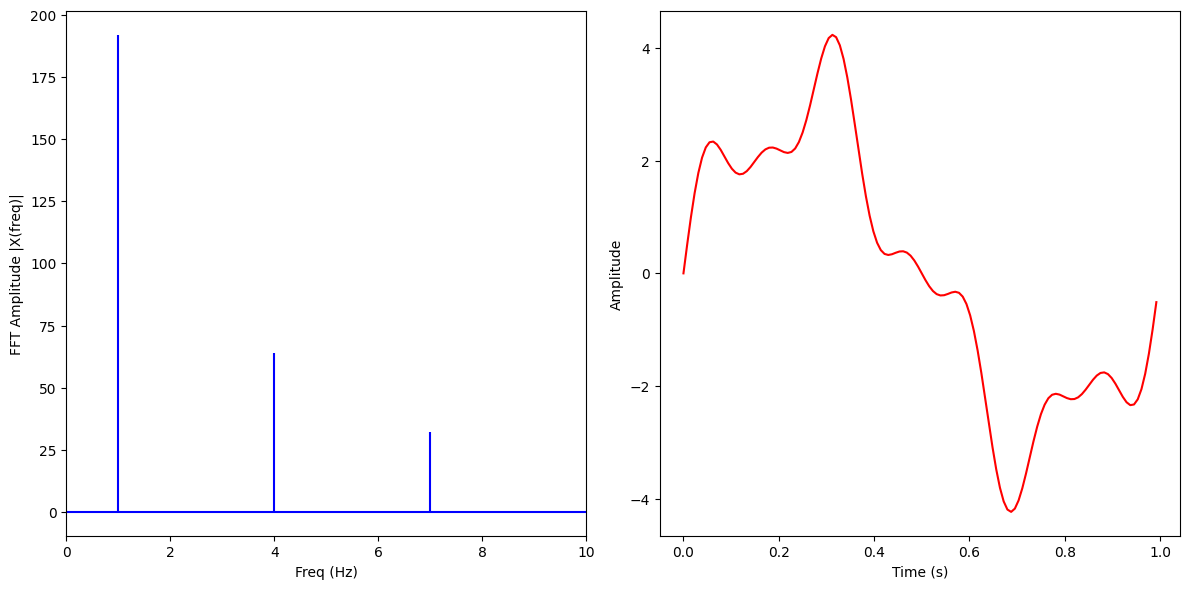

In [50]:
from scipy.fftpack import fft, ifft #FFT in Scipy

X = fft(x)

plt.figure(figsize = (12, 6))
plt.subplot(121)

plt.stem(freq, np.abs(X), 'b', \
         markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('FFT Amplitude |X(freq)|')
plt.xlim(0, 10)

plt.subplot(122)
plt.plot(t, ifft(X), 'r')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.tight_layout()
plt.show()

In [51]:
%timeit fft(x)

4.46 µs ± 123 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [2]:
import urllib.request
from scipy.io import wavfile

urllib.request.urlretrieve('http://www-users.math.umn.edu/~jwcalder/5467/classical.wav','classical.wav')
fs, data = wavfile.read('classical.wav')
f = (data[:,0] + data[:,1])/2  #convert from stereo to mono
print(f.shape)
print(fs)

(2161965,)
22050


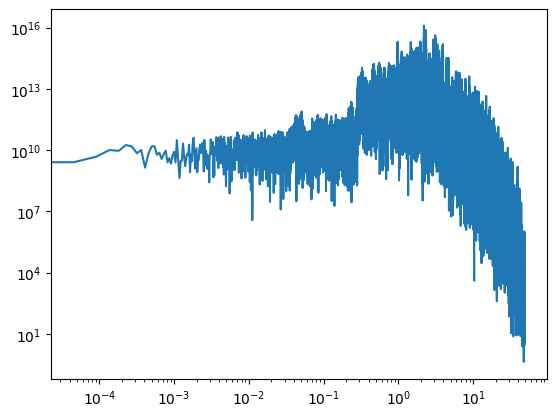

In [9]:
from scipy.fft import fft
import matplotlib.pyplot as plt
import numpy as np

n = len(f)
Df = fft(f)
plt.loglog(np.arange(n//2)/fs,np.absolute(Df[:n//2])**2)

In [16]:
ls = np.logspace(0,np.log10(n//2),50)
ls

array([1.00000000e+00, 1.32781984e+00, 1.76310552e+00, 2.34108648e+00,
       3.10854107e+00, 4.12758249e+00, 5.48068591e+00, 7.27736346e+00,
       9.66302756e+00, 1.28307597e+01, 1.70369372e+01, 2.26219832e+01,
       3.00379180e+01, 3.98849434e+01, 5.29600190e+01, 7.03213637e+01,
       9.33741017e+01, 1.23983984e+02, 1.64628394e+02, 2.18596847e+02,
       2.90257230e+02, 3.85409307e+02, 5.11754123e+02, 6.79517276e+02,
       9.02276518e+02, 1.19806066e+03, 1.59080871e+03, 2.11230736e+03,
       2.80476361e+03, 3.72422076e+03, 4.94509420e+03, 6.56619417e+03,
       8.71872287e+03, 1.15768932e+04, 1.53720284e+04, 2.04112842e+04,
       2.71025081e+04, 3.59872478e+04, 4.77845815e+04, 6.34493152e+04,
       8.42492594e+04, 1.11867838e+05, 1.48540334e+05, 1.97234802e+05,
       2.61892283e+05, 3.47745768e+05, 4.61743728e+05, 6.13112482e+05,
       8.14102915e+05, 1.08098200e+06])

In [19]:
x = []
y = []
for i in range(len(ls)-1):
    points = (np.absolute(Df[:n//2])**2)[int(ls[i]):int(ls[i+1])]
    if len(points):
        x.append((int(ls[i])+int(ls[i+1]))/2)
        y.append(points.sum()/(int(ls[i+1])-int(ls[i])))

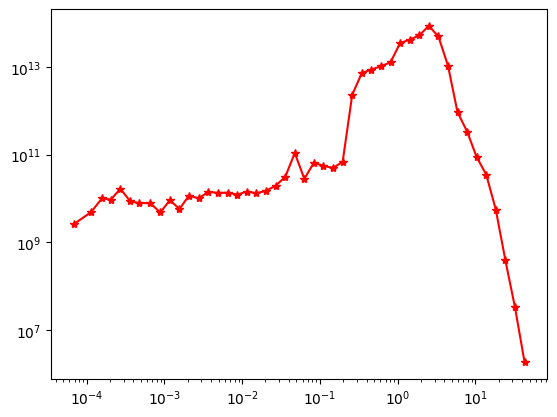

In [26]:
plt.loglog(np.array(x)/fs,y,"r*-")

In [38]:
from scipy.fft import fft
from scipy.fft import ifft

block_size = 1000
threshold = 5000

#Number of nonzero Fourier coefficients
num=0

#Array to store decompressed audio
f_comp = np.zeros(len(f))

#Window function
for i in range(0,len(f)-block_size,block_size):

    #Main block
    f_block = f[i:i+block_size]

    #Take fft of f_block, then set all coefficients with abs < threshold to zero
    #Then take ifft of the results and store in f_comp
    #keep track of number of nonzero coefficients in the variable num
    Df = fft(f_block)
    ind = np.absolute(Df)<threshold
    Df[ind] = 0
    f_comp[i:i+block_size] = ifft(Df).real
    num += np.sum(~ind) #Number of nonzero coefficients

print('Compression ratio: %f:1'%(len(f_comp)/num))



Compression ratio: 5.896472:1


In [ ]:
from IPython.display import Audio

Audio(f_comp,rate=fs,autoplay=True)

In [40]:
from scipy.fft import fft
from scipy.fft import ifft

block_size = 1000
threshold = 8000

#Window function
N = int(block_size/2)
W = np.sin(np.pi*(np.arange(2*N)+0.5)/(2*N))**2

#Number of nonzero Fourier coefficients
num=0

#Array to store decompressed audio
f_comp = np.zeros(len(f))

#Window function
for i in range(0,len(f)-block_size,int(block_size/2)):

    #Main block
    f_block = f[i:i+block_size]
    Df = fft(f_block)
    ind = np.absolute(Df)<threshold
    Df[ind] = 0
    f_comp[i:i+block_size] += W*ifft(Df).real
    num += np.sum(~ind) #Number of nonzero coefficients

print('Compression ratio: %f:1'%(len(f_comp)/num))

Compression ratio: 3.817743:1


In [ ]:
from IPython.display import Audio

Audio(f_comp,rate=fs,autoplay=True)